<a href="https://colab.research.google.com/github/AnnaMakarova28/carprice/blob/main/Hometasks/Pro/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [1]:
# !pip install gdown -q

In [2]:
# import gdown

# # url = 'https://drive.google.com/uc?id=1Jt_qbTvrAIJ516Rg-QW2vzpFkbdF0ezm'
# url = 'https://disk.yandex.ru/d/g9LzEzOc_O-r1w'
# output = 'Data.zip'
# gdown.download(url, output, quiet=False)

In [3]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [4]:
import pandas as pd
import numpy as np

features = pd.read_csv('/content/Data/AGGS_FINAL.csv', parse_dates=['report_dt'])
contracts = pd.read_csv('/content/Data/CONTRACTS_FINAL.csv', parse_dates=['contract_date'])
campaigns = pd.read_csv('/content/Data/CAMPAINGS.csv')
people = pd.read_csv('/content/Data/PEOPLE_IN_CAMPAINGS_FINAL.csv', parse_dates=['delivery_date'])

In [5]:
features.head()

,Unnamed: 0,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
0,104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
1,38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
2,227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
3,304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
4,239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow


In [6]:
contracts.head()

,Unnamed: 0,user_id,contract_date,product_id,contract_id
0,39735,4008279,2024-11-03,1,0001_2024-11-03_4008279
1,44062,2079035,2024-11-08,1,0001_2024-11-08_2079035
2,9286,103088,2024-11-13,1,0001_2024-11-13_103088
3,45573,2026788,2024-11-02,1,0001_2024-11-02_2026788
4,150378,52269,2024-11-17,1,0001_2024-11-17_52269


In [7]:
campaigns.head()

,Unnamed: 0,campaing_id,product_id,channel
0,0,iddqd,1,push
1,1,idclip,1,sms
2,2,iddt,1,banner
3,3,idkfa,1,other_ads


In [8]:
people.head()

,Unnamed: 0,campaing_id,user_id,t_flag,delivery_date
0,29299,idclip,1099975,1,2024-11-06
1,36627,iddqd,1162,1,2024-11-08
2,134015,iddqd,42991,1,2024-11-07
3,57441,idclip,142343,0,unknown
4,48671,iddqd,24623,0,unknown


In [9]:
contracts['product_id'].value_counts()

,count
product_id,
1,286316


In [10]:
campaigns['product_id'].value_counts()

,count
product_id,
1,4


In [11]:
camp_people = people.merge(campaigns, on='campaing_id', how='inner')
camp_people.head()

,Unnamed: 0_x,campaing_id,user_id,t_flag,delivery_date,Unnamed: 0_y,product_id,channel
0,29299,idclip,1099975,1,2024-11-06,1,1,sms
1,36627,iddqd,1162,1,2024-11-08,0,1,push
2,134015,iddqd,42991,1,2024-11-07,0,1,push
3,57441,idclip,142343,0,unknown,1,1,sms
4,48671,iddqd,24623,0,unknown,0,1,push


In [12]:
camp_people['delivery_date'].value_counts().sort_index()

,count
delivery_date,
2024-11-04,55707
2024-11-05,55241
2024-11-06,55589
2024-11-07,55943
2024-11-08,37520
unknown,260000


In [13]:
camp_people['purchase_period_start'] = camp_people['delivery_date'].apply(lambda x:
                                                             pd.to_datetime(x, format="%Y-%m-%d")
                                                             if x != 'unknown'
                                                             else pd.to_datetime('2024-11-01', format="%Y-%m-%d"))

In [14]:
camp_people['purchase_period_end'] = camp_people['delivery_date'].apply(lambda x:
                                                             pd.to_datetime(x, format="%Y-%m-%d") + pd.Timedelta(days=14)
                                                             if x != 'unknown'
                                                             else pd.to_datetime('2024-11-21', format="%Y-%m-%d"))

In [15]:
camp_people.head()

,Unnamed: 0_x,campaing_id,user_id,t_flag,delivery_date,Unnamed: 0_y,product_id,channel,purchase_period_start,purchase_period_end
0,29299,idclip,1099975,1,2024-11-06,1,1,sms,2024-11-06,2024-11-20
1,36627,iddqd,1162,1,2024-11-08,0,1,push,2024-11-08,2024-11-22
2,134015,iddqd,42991,1,2024-11-07,0,1,push,2024-11-07,2024-11-21
3,57441,idclip,142343,0,unknown,1,1,sms,2024-11-01,2024-11-21
4,48671,iddqd,24623,0,unknown,0,1,push,2024-11-01,2024-11-21


In [16]:
data = camp_people.merge(
    contracts[['user_id', 'contract_date', 'contract_id']],
    on='user_id',
    how='left'
)

In [17]:
data.head()

,Unnamed: 0_x,campaing_id,user_id,t_flag,delivery_date,Unnamed: 0_y,product_id,channel,purchase_period_start,purchase_period_end,contract_date,contract_id
0,29299,idclip,1099975,1,2024-11-06,1,1,sms,2024-11-06,2024-11-20,2024-11-11,0001_2024-11-11_1099975
1,36627,iddqd,1162,1,2024-11-08,0,1,push,2024-11-08,2024-11-22,2024-11-13,0001_2024-11-13_1162
2,134015,iddqd,42991,1,2024-11-07,0,1,push,2024-11-07,2024-11-21,NaT,NaN
3,57441,idclip,142343,0,unknown,1,1,sms,2024-11-01,2024-11-21,2024-11-17,0001_2024-11-17_142343
4,48671,iddqd,24623,0,unknown,0,1,push,2024-11-01,2024-11-21,NaT,NaN


In [18]:
sum(data['contract_date'].notna()) / len(data['contract_date'])

0.649298076923077

In [19]:
is_treatment = data['t_flag'] == 1
is_control = data['t_flag'] == 0

data['hit'] = 0

data.loc[
    is_treatment &
    data['contract_date'].notna() &
    (data['contract_date'] >= data['purchase_period_start']) &
    (data['contract_date'] <= data['purchase_period_end']),
    'hit'
] = 1

data.loc[
    is_control &
    data['contract_date'].notna() &
    (data['contract_date'] >= data['purchase_period_start']) &
    (data['contract_date'] <= data['purchase_period_end']),
    'hit'
] = 1

In [20]:
data['contract_date'][0] > data['purchase_period_start'][0]

True

In [21]:
data.head()

,Unnamed: 0_x,campaing_id,user_id,t_flag,delivery_date,Unnamed: 0_y,product_id,channel,purchase_period_start,purchase_period_end,contract_date,contract_id,hit
0,29299,idclip,1099975,1,2024-11-06,1,1,sms,2024-11-06,2024-11-20,2024-11-11,0001_2024-11-11_1099975,1
1,36627,iddqd,1162,1,2024-11-08,0,1,push,2024-11-08,2024-11-22,2024-11-13,0001_2024-11-13_1162,1
2,134015,iddqd,42991,1,2024-11-07,0,1,push,2024-11-07,2024-11-21,NaT,NaN,0
3,57441,idclip,142343,0,unknown,1,1,sms,2024-11-01,2024-11-21,2024-11-17,0001_2024-11-17_142343,1
4,48671,iddqd,24623,0,unknown,0,1,push,2024-11-01,2024-11-21,NaT,NaN,0


In [22]:
data['campaign_end'] = pd.to_datetime('2024-11-30', format="%Y-%m-%d")

In [23]:
target_df = (
    data.groupby(
        ['user_id', 'campaign_end', 'channel', 'campaing_id', 't_flag'],
        as_index=False
    )['hit']
    .max()
    .rename(columns={'hit': 'target'})
)

target_df

,user_id,campaign_end,channel,campaing_id,t_flag,target
0,1,2024-11-30,push,iddqd,1,0
1,1,2024-11-30,sms,idclip,0,0
2,2,2024-11-30,push,iddqd,0,0
3,3,2024-11-30,push,iddqd,0,0
4,4,2024-11-30,push,iddqd,0,0
...,...,...,...,...,...,...
519995,4119995,2024-11-30,banner,iddt,1,1
519996,4119996,2024-11-30,banner,iddt,0,0
519997,4119997,2024-11-30,banner,iddt,1,0
519998,4119998,2024-11-30,banner,iddt,0,1


In [24]:
target_df.groupby(['channel', 't_flag']).size().unstack(fill_value=0)

t_flag,0,1
channel,,
banner,60000,60000
other_ads,60000,60000
push,80000,80000
sms,60000,60000


In [25]:
conv = (
    target_df.groupby(['channel', 't_flag'])['target']
    .mean()
    .reset_index()
)

conv

,channel,t_flag,target
0,banner,0,0.400733
1,banner,1,0.602717
2,other_ads,0,0.400733
3,other_ads,1,0.602717
4,push,0,0.202150
5,push,1,0.601738
6,sms,0,0.684917
7,sms,1,0.201167


In [26]:
pivot_conv = conv.pivot(index='channel', columns='t_flag', values='target')
pivot_conv.columns = ['control_rate', 'treatment_rate']
pivot_conv['uplift'] = pivot_conv['treatment_rate'] - pivot_conv['control_rate']
pivot_conv = pivot_conv.reset_index()
pivot_conv.sort_values('uplift', ascending=False)

,channel,control_rate,treatment_rate,uplift
2,push,0.202150,0.601738,0.399588
0,banner,0.400733,0.602717,0.201983
1,other_ads,0.400733,0.602717,0.201983
3,sms,0.684917,0.201167,-0.483750


In [27]:
user_channel_counts = (
    target_df.groupby('user_id')['channel']
    .nunique()
    .reset_index(name='n_channels')
)

user_channel_counts['n_channels'].value_counts().sort_index()

,count
n_channels,
1,400000
2,60000


60_000 клиентов с 2 каналами доставки сообщений (15%)

In [28]:
target_df.duplicated(['user_id', 'campaing_id']).sum()

np.int64(0)

### ваши выводы здесь


• данные содержат четыре канала коммуникации: push, banner, other_ads, и sms. наиболее высокий uplift показывает канал push - примерно 0.40, что означает существенный прирост вероятности покупки после коммуникации

• каналы banner и other_ads имеют умеренный положительный эффект uplift около 0.20. это говорит о наличии стимулирующего эффекта однако он заметно ниже чем у push

• канал sms демонстрирует отрицательный uplift около −0.48. Вероятность покупки в контрольной группе выше, чем у клиентов получивших сообщение поэтому коммуникация через этот канал может снижать конверсию

• около 60 тыс клиентов (15%) участвовали сразу в двух каналах коммуникации. такое пересечение усложняет оценку причинного эффекта конкретного канала и может вносить смещение в оценку uplift

• после агрегации дубликатов по user_id и campaing_id не обнаружено. Это подтверждает корректность формирования таргета и позволяет использовать данные для дальнейшего моделирования uplift


<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [29]:
target_df.head()

,user_id,campaign_end,channel,campaing_id,t_flag,target
0,1,2024-11-30,push,iddqd,1,0
1,1,2024-11-30,sms,idclip,0,0
2,2,2024-11-30,push,iddqd,0,0
3,3,2024-11-30,push,iddqd,0,0
4,4,2024-11-30,push,iddqd,0,0


In [30]:
# target_month = '2024-11'
# features_month = '2024-09'

target_df['report_dt'] = pd.to_datetime('2024-11-30')

target_df['feature_dt'] = target_df['report_dt'] - pd.DateOffset(months=2)
target_df.head()


,user_id,campaign_end,channel,campaing_id,t_flag,target,report_dt,feature_dt
0,1,2024-11-30,push,iddqd,1,0,2024-11-30,2024-09-30
1,1,2024-11-30,sms,idclip,0,0,2024-11-30,2024-09-30
2,2,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30
3,3,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30
4,4,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30


In [31]:
features.head()

,Unnamed: 0,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
0,104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
1,38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
2,227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
3,304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
4,239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow


In [32]:
data_model = target_df.merge(
    features,
    left_on=['user_id', 'feature_dt'],
    right_on=['user_id', 'report_dt'],
    how='left'
)

In [33]:
data_model.head()

,user_id,campaign_end,channel,campaing_id,t_flag,target,report_dt_x,feature_dt,Unnamed: 0,x1,...,x3,x4,x5,x6,x7,x8,x9,report_dt_y,age,city
0,1,2024-11-30,push,iddqd,1,0,2024-11-30,2024-09-30,0,1.177697,...,1.729425,-2.089231,1.307060,-0.436698,0.265101,-1.068295,0.809188,2024-09-30,31,Ufa
1,1,2024-11-30,sms,idclip,0,0,2024-11-30,2024-09-30,0,1.177697,...,1.729425,-2.089231,1.307060,-0.436698,0.265101,-1.068295,0.809188,2024-09-30,31,Ufa
2,2,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30,1,1.011344,...,-0.940343,-2.168505,0.595523,-1.301440,-1.173930,0.875189,1.805140,2024-09-30,26,Moscow
3,3,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30,2,0.821249,...,2.545513,-0.737370,1.326130,0.815585,-0.530246,-1.624725,1.130743,2024-09-30,20,Moscow
4,4,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30,3,1.326766,...,-0.188080,-1.759102,2.423625,-0.782383,1.604272,-0.767207,-0.122618,2024-09-30,23,Ufa


In [34]:
data_model = data_model.drop(columns=['report_dt_y','Unnamed: 0'])
data_model = data_model.rename(columns={'report_dt_x': 'report_dt'})

In [35]:
data_model.isna().mean().sort_values(ascending=False).head(10)

,0
user_id,0.0
campaign_end,0.0
channel,0.0
campaing_id,0.0
t_flag,0.0
target,0.0
report_dt,0.0
feature_dt,0.0
x1,0.0
x2,0.0


In [36]:
data_model['age'].isna().mean()

np.float64(0.0)

In [37]:
data_model.head()

,user_id,campaign_end,channel,campaing_id,t_flag,target,report_dt,feature_dt,x1,x2,x3,x4,x5,x6,x7,x8,x9,age,city
0,1,2024-11-30,push,iddqd,1,0,2024-11-30,2024-09-30,1.177697,1.541399,1.729425,-2.089231,1.307060,-0.436698,0.265101,-1.068295,0.809188,31,Ufa
1,1,2024-11-30,sms,idclip,0,0,2024-11-30,2024-09-30,1.177697,1.541399,1.729425,-2.089231,1.307060,-0.436698,0.265101,-1.068295,0.809188,31,Ufa
2,2,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30,1.011344,1.722951,-0.940343,-2.168505,0.595523,-1.301440,-1.173930,0.875189,1.805140,26,Moscow
3,3,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30,0.821249,1.566195,2.545513,-0.737370,1.326130,0.815585,-0.530246,-1.624725,1.130743,20,Moscow
4,4,2024-11-30,push,iddqd,0,0,2024-11-30,2024-09-30,1.326766,2.319796,-0.188080,-1.759102,2.423625,-0.782383,1.604272,-0.767207,-0.122618,23,Ufa


при объединении ничего не потеряли

In [38]:
data_model.groupby(['channel','t_flag']).size().unstack()

t_flag,0,1
channel,,
banner,60000,60000
other_ads,60000,60000
push,80000,80000
sms,60000,60000


In [39]:
conv = data_model.groupby(['channel','t_flag'])['target'].mean().unstack()

conv['uplift'] = conv[1] - conv[0]

conv

t_flag,0,1,uplift
channel,,,
banner,0.400733,0.602717,0.201983
other_ads,0.400733,0.602717,0.201983
push,0.202150,0.601738,0.399588
sms,0.684917,0.201167,-0.483750


In [40]:
data_model.groupby('channel')['user_id'].count()

,user_id
channel,
banner,120000
other_ads,120000
push,160000
sms,120000


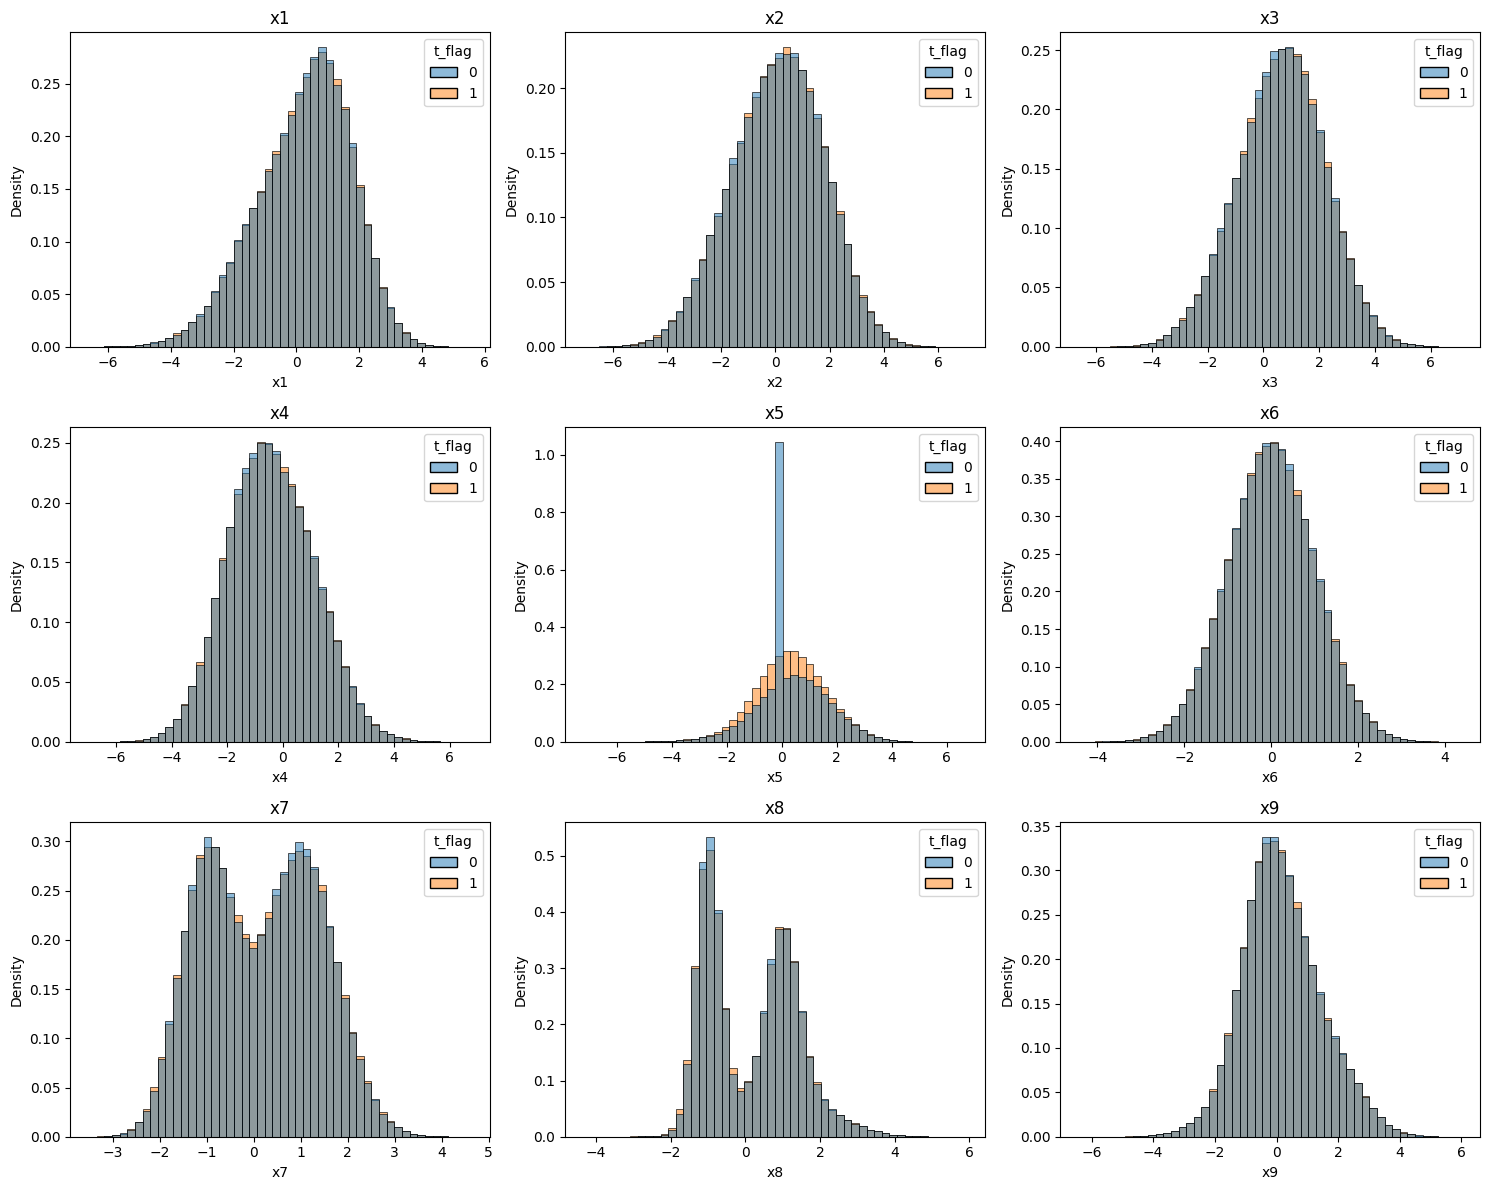

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

features_list = [f'x{i}' for i in range(1,10)]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(features_list):
    ax = axes[i//3, i%3]
    sns.histplot(
        data=data_model,
        x=col,
        hue='t_flag',
        bins=50,
        ax=ax,
        stat="density",
        common_norm=False
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

### ваши выводы здесь

• во всех каналах наблюдается полный баланс между контрольной и целевой группой. для banner other_ads и sms в каждой группе по 60 тыс клиентов, для push - по 80 тыс. это говорит о корректной рандомизации кампаний

• размеры выборок достаточно большие для каждого канала. общее число наблюдений - 120 тыс для banner other_ads и sms и 160 тыс для push

• отсутствуют каналы с очень маленьким числом клиентов. все каналы потенциально могут быть использованы при построении uplift модели

• баланс treatment и control подтверждает корректность экспериментального дизайна кампаний и позволяет корректно оценивать причинный эффект коммуникаций

• для все признаков кроме х5 распределения контрольной и целевой групп практически совпадают что говорит о корректной рандомизации

• для признака x5 наблюдается небольшое отличие распределений однако оно не выглядит критичным

• в целом существенного смещения между treatment и control не обнаружено и данные можно использовать для uplift моделирования

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [9]:
# !pip install catboost
# !pip install scikit-learn==1.3.2 scikit-uplift -q

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     cross_validate,
                                     StratifiedKFold)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from causalml.dataset import make_uplift_classification
from causalml.inference.tree import UpliftRandomForestClassifier

import optuna

from catboost import CatBoostClassifier

ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py)

In [14]:
# !pip install scikit-uplift

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.5 MB/s eta 0:00:00


In [2]:
from sklift.models import (SoloModel,
                           TwoModels,
                           ClassTransformation,
                           ClassTransformationReg)
from sklift.metrics import (uplift_at_k,
                            uplift_auc_score,
                            qini_auc_score,
                            make_uplift_scorer)

In [19]:
# !pip install scikit-learn==1.3.2 scikit-uplift -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
causalml 0.16.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.3.2 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
esda 2.8.2 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.
imbalanced-learn 0.14.1 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.3.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
libpy

In [1]:
from sklift.viz import plot_qini_curve, plot_uplift_curve

In [ ]:

RANDOM_STATE = 42

df, x_names = make_uplift_classification(
                                         treatment_name=['control', 'treatment1'],
                                         y_name = 'target',
                                         n_classification_features = 6,
                                         n_classification_informative = 5,
                                         n_samples = 80000,
                                         random_seed = RANDOM_STATE,
                                         positive_class_proportion=0.4,
                                         delta_uplift_increase_dict={'treatment1': 0.7})
df['treatment_group_key'] = df['treatment_group_key'].replace({'control':0, 'treatment1':1})
df.head()


df.treatment_group_key = df.treatment_group_key.astype('int')
df.head(5)
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = 'target'),
                                                    df.target,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=df.target)
<h2>Обучение первой модели</h2>
Как решать задачу? В простейшем случае можно поступить следующим образом:

1. Обучим модель на X_train (с колонкой с флагом коммуникации)
2. Для построения предсказаний (predict_proba) uplift подадим X_test дважды - сначала указав в качестве флага коммуникации 0, а затем указав в качестве флага коммуникации 1

Этот подход называется Solomodel.
model = LogisticRegression(random_state=RANDOM_STATE)
model.fit(X_train, y_train)
X_test_0 = X_test.copy()
X_test_0['treatment_group_key'] = 0
X_test_0.head()
y_pred_0 = model.predict_proba(X_test_0)[:,1]
X_test_1 = X_test.copy()
X_test_1['treatment_group_key'] = 1
X_test_1.head()
y_pred_1 = model.predict_proba(X_test_1)[:,1]
uplift_0 = y_pred_1 - y_pred_0
uplift_pd = pd.DataFrame(data = uplift_0, index = X_test.index, columns=['uplift'])
uplift_pd = uplift_pd.sort_values(by='uplift', ascending=False)
sns.histplot(data = uplift_pd, x=uplift_0).set_title('uplift')
plt.show()
<h2>Metalearners
<h3> Metalearners: Solomodel </h3>
Воспользуемся аналогичным подходом, как в предыдущем примере, но воспользуемся классом Solomodel из библиотеки Sklift. В качестве внутренней модели всё также будем использовать логистическую регрессию.
X_train.head()
sm = SoloModel(estimator=model)
sm.fit(X_train.drop(columns='treatment_group_key'),
       y_train,
       treatment=X_train['treatment_group_key'])
uplift_1 = sm.predict(X_test.drop(columns='treatment_group_key'))
uplift_pd = pd.DataFrame(data = uplift_1, index = X_test.index, columns=['uplift'])
uplift_pd = uplift_pd.sort_values(by='uplift', ascending=False)
sns.histplot(data = uplift_pd, x=uplift_0).set_title('uplift')
plt.show()
np.linalg.norm(uplift_0 - uplift_1) / np.linalg.norm(uplift_1)
Таким образом мы получили идентичные результаты, как с наивным подходом, так и с помощью Solomodel. Посмотрим, какое получилось качество Uplift
uplift_at_k(y_true=y_test,
            uplift=uplift_1,
            treatment=X_test['treatment_group_key'],
            strategy='by_group',
            k=0.2)
uplift_auc_score(y_true=y_test,
                 uplift=uplift_1,
                 treatment=X_test['treatment_group_key'])
plot_uplift_curve(y_true=y_test,
                  uplift=pd.Series(uplift_1, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
qini_auc_score(y_true=y_test,
               uplift=pd.Series(uplift_1, index=X_test.index),
               treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_1, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
Получившееся качество довольно невысоко. Попробуем другие подходы и другие модели в качестве базовых. Также попробуем осуществить тюнинг гиперпараметров. Далее в качестве метрики будем использовать qini_auc_score.
<h3> Metalearners: Twomodels </h3> Здесь мы уже будем использовать две модели, которые обучаются на контрольной и целевой частях датасета. Рассмотрим подход с использованием независимых и зависимых моделей, как мы обсудили ранее.
model_1 = LogisticRegression(random_state=RANDOM_STATE+1)
model_2 = LogisticRegression(random_state=RANDOM_STATE+2)
#независимые модели
tm_ind = TwoModels(estimator_trmnt=model_1,
                   estimator_ctrl=model_2,
                   method='vanilla')
tm_ind.fit(X_train.drop(columns='treatment_group_key'),
           y_train,
           treatment=X_train['treatment_group_key'])
uplift_2 = tm_ind.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
               uplift=pd.Series(uplift_2, index=X_test.index),
               treatment=X_test['treatment_group_key'])
#зависимые модели
tm_not_ind = TwoModels(estimator_trmnt=model_1,
                       estimator_ctrl=model_2,
                       method='ddr_control')
tm_not_ind.fit(X_train.drop(columns='treatment_group_key'),
               y_train,
               treatment=X_train['treatment_group_key'])
uplift_3 = tm_not_ind.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
               uplift=pd.Series(uplift_3, index=X_test.index),
               treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_3, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
Несколько лучше, чем было раньше. Есть три гипотезы о том, как можно попробовать улучшить качество в рамках использования Metalearners
1. Перед подачей в LogisticRegression данные необходимо предобрабатывать (как минимум осуществлять скейлинг), однако как создать pipeline при условии того, что мы пользуемся Uplift моделью (инференс модели отличается от обучения еще и тем, что используется флаг коммуникации) не совсем понятно.
2. Тюнинг гиперпараметров. Однако здесь возникает аналогичная проблема, связанная с тем, что "стандартная" кросс-валидация ничего не знает про Uplift-моделирование.
3. Можно попробовать другие модели в качестве базовых (например градиентный бустинг), но здесь возникает проблема с калибровкой моделей

<h3> Использование пайплайнов для uplift-моделирования </h3>
pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('model_uplift', tm_not_ind)
])
pipe.fit(X_train.drop(columns='treatment_group_key'),
         y_train,
         model_uplift__treatment=X_train['treatment_group_key'])
uplift_4 = pipe.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
               uplift=pd.Series(uplift_4, index=X_test.index),
               treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_4, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
У нас получилось несколько улучшить качество таким образом. Важно понимать, что параметр model_uplift__treatment в методе fit формируется следующим образом: название этапа (в данном случае это model_uplift) + '__' + название параметра. Здесь мы передаем колонку с флагом коммуникации.
<h3> Калибровка моделей для Uplift моделирования</h3> Чтобы использовать какие-то другие внутренние модели помимо логистической регрессии, нам необходимо осуществлять калибровку моделей, чтобы они выдавали честные вероятности, только в этом случае мы сможем корректно считать uplift. Можно воспользоваться следующим подходом.
skf = StratifiedKFold(n_splits=5,
                      random_state=RANDOM_STATE,
                      shuffle=True)
model_1_cb = CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE, thread_count=-1)
model_2_cb = CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE+1, thread_count=-1)

calib_model_1 = CalibratedClassifierCV(estimator=model_1_cb, method='isotonic', cv=skf)
calib_model_2 = CalibratedClassifierCV(estimator=model_2_cb, method='isotonic', cv=skf)
tm_catboost = TwoModels(estimator_trmnt=calib_model_1,
                        estimator_ctrl=calib_model_2)
tm_catboost.fit(X_train.drop(columns='treatment_group_key'),
                y_train,
                treatment=X_train['treatment_group_key'])
uplift_5 = tm_catboost.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
                 uplift=uplift_5,
                 treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_5, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
sm_catboost = SoloModel(estimator=calib_model_1)
sm_catboost.fit(X_train.drop(columns='treatment_group_key'),
                y_train,
                treatment=X_train['treatment_group_key'])
uplift_6 = sm_catboost.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
                 uplift=uplift_6,
                 treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_6, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
<h3>Тюнинг гиперпараметров для Uplift моделирования </h3> Напишем свою кросс-валидацию для вычисления qini_score.
X_train.head()
Пишем свою кастомную кросс-валидацию под новый scorer
qini_scorer = make_uplift_scorer("qini_auc_score", X_train['treatment_group_key'])


# Use this object in model selection functions
cross_validate(tm_ind,
               X=X_train.drop(columns='treatment_group_key'),
               y=y_train,
               fit_params={'treatment': X_train['treatment_group_key']},
               scoring=qini_scorer,
               cv=skf,
               n_jobs=-1,
               return_train_score=True)

def objective_tm_lr(trial):

    param = {
            'C_1':trial.suggest_float("C_1", 0, 3),
            'C_2':trial.suggest_float("C_2", 0, 3),
            'method':trial.suggest_categorical("method", ['vanilla', 'ddr_control', 'ddr_treatment'])
    }
    #если бы у нас была не логрегрессия, то мы бы еще обернули в CalibratedClassifier
    model_1 = LogisticRegression(random_state=RANDOM_STATE+1, C=param['C_1'])
    model_2 = LogisticRegression(random_state=RANDOM_STATE+2, C=param['C_2'])

    tm = TwoModels(estimator_trmnt=model_1,
                       estimator_ctrl=model_2,
                       method=param['method'])

    pipe = Pipeline(steps=[('scaler', MinMaxScaler()),
                           ('model_uplift', tm)])

    qini_scorer = make_uplift_scorer("qini_auc_score", X_train['treatment_group_key'])

    cross_val = cross_validate(pipe,
                               X=X_train.drop(columns='treatment_group_key'),
                               y=y_train,
                               fit_params={'model_uplift__treatment':X_train['treatment_group_key']},
                               scoring=qini_scorer,
                               cv=skf,
                               n_jobs=-1,
                               return_train_score=True)

    #мы ищем не просто самую лучшую модель, а самую стабильную
    return cross_val['test_score'].mean() - cross_val['test_score'].std()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_tm = optuna.create_study(direction="maximize")
study_tm.optimize(objective_tm_lr,
                  n_trials=500,
                  show_progress_bar=True)
<div class="alert alert-warning"><b>Подумайте над следующим вопросом.</b> Вообще говоря, тот подход, который использовался для скейлинга для обучения Twomodels не совсем верен. Twomodels предполагает обучение двух независимых моделей, каждая из которых обучается на своём датасете (контрольная и целевая выборка) и соответственно, скейлинг (как и любую другую предобработку) каждого датасета перед подачей в модель, вообще говоря, необходимо проводить независимо. Но тем не менее, такой подход, вполне допустим. Объясните, почему это так.  </div>
Аналогичным образом можно сделать тюнинг другого Metalearner'а с другими базовыми алгоритмами.
<h2>Преобразование классов
ct = ClassTransformation(model_1_cb)
# fit the model
ct = ct.fit(X_train.drop(columns='treatment_group_key'),
                y_train,
                treatment=X_train['treatment_group_key'])
# predict uplift
uplift_ct = ct.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
                 uplift=uplift_ct,
                 treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_ct, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
ct = ClassTransformationReg(estimator=LinearRegression(),
                            propensity_estimator=LogisticRegression())
# fit the model
ct = ct.fit(X_train.drop(columns='treatment_group_key'),
                y_train,
                treatment=X_train['treatment_group_key'])
# predict uplift
uplift_ct = ct.predict(X_test.drop(columns='treatment_group_key'))
qini_auc_score(y_true=y_test,
                 uplift=uplift_ct,
                 treatment=X_test['treatment_group_key'])
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_ct, index=X_test.index),
                  treatment=X_test['treatment_group_key'])
plt.show()
<div class="alert alert-warning"><b>Подумайте над следующим вопросом.</b> Почему при трансформации классов  мы не использовали калибровку вероятностей для вычисления qini_score?  </div>
В части использования в пайплайнах и тюнинга модели здесь применимо всё, что говорилось про Metalearners.
<h2> Алгоритмы, основанные на Uplift-деревьях </h2> Продемонстрируем работу случайного леса на основе Uplift деревьев
X_train.head(5)
uplift_forest = UpliftRandomForestClassifier(control_name='0',
                                             random_state=RANDOM_STATE)
У библиотеки CausalML несколько другой синтаксис, чем у Sklift, поэтому колонка с флагом коммуникации должна быть категориальной.
X_train['treatment_group_key'] = X_train['treatment_group_key'].astype('str')
X_test['treatment_group_key'] = X_test['treatment_group_key'].astype('str')
uplift_forest.fit(X=X_train.drop(columns='treatment_group_key').values,
                  y=y_train.values,
                  treatment=X_train['treatment_group_key'].values)
uplift_fr = uplift_forest.predict(X=X_test.drop(columns='treatment_group_key').values)
qini_auc_score(y_true=y_test,
                 uplift=uplift_fr.reshape(-1),
                 treatment=X_test['treatment_group_key'].astype('int'))
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_fr.reshape(-1), index=X_test.index),
                  treatment=X_test['treatment_group_key'].astype(int))
plt.show()
<h1> Бонус: стратификация при Uplift-моделировании </h1> В данном ноутбуке мы упустили одну важную вещь, а именно: стратификация. То есть представим себе ситуацию, когда продукт, для которого вы планируете построить модель имеет очень низкую долю покупок (например, 3-4%, что довольно типично). Соответственно, при разбиении необходимо учесть стратификацию по таргету. Однако, в данном случае, может возникнуть проблема: при стратификации по таргету есть риск того, что доли целевой и контрольной группы будут отличаться в тренировочной и тестовой выборке. Соответственно, <b>необходимо стратифицировать дополнительно по флагу коммуникации.</b> Это можно сделать следующим образом: создаем новую колонку, которую представим парами значение таргета _ значение коммуникации
to_stratify = df['target'].astype(str) + '_' + df['treatment_group_key'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = 'target'),
                                                    df.target,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=to_stratify)


In [42]:
# !pip install scikit-uplift catboost optuna -q

In [43]:
feature_cols = ['city', 'age'] + [f'x{i}' for i in range(1, 10)]
cat_cols = ['city']
num_cols = ['age'] + [f'x{i}' for i in range(1, 10)]

In [51]:
def prepare_channel_dataset(data, channel_name):
    df = data.copy()

    df = df[df['channel'] == channel_name].copy()

    X = df[feature_cols].copy()
    X = pd.get_dummies(X, columns=['city'], drop_first=False)
    y = df['target'].astype(int).copy()
    treatment = df['t_flag'].astype(int).copy()

    return df, X, y, treatment

In [52]:
def prepare_raw_dataset(data, channel_name):
    df = data[data['channel'] == channel_name].copy()

    X = df[feature_cols].copy()
    y = df['target'].astype(int)
    treatment = df['t_flag'].astype(int)

    return df, X, y, treatment

In [45]:
from sklearn.model_selection import train_test_split

def make_split(X, y, treatment, test_size=0.3, random_state=42):
    strat = treatment.astype(str) + "_" + y.astype(str)

    X_train, X_test, y_train, y_test, tr_train, tr_test = train_test_split(
        X, y, treatment,
        test_size=test_size,
        random_state=random_state,
        stratify=strat
    )

    return X_train, X_test, y_train, y_test, tr_train, tr_test

solomodel

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklift.models import SoloModel
from sklift.metrics import qini_auc_score

solo_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1
    ))
])

solo_model = SoloModel(
    estimator=solo_pipe,
    method='treatment_interaction'
)

In [71]:
df_ch, X, y, treatment = prepare_channel_dataset(data_model, 'push')
X_train, X_test, y_train, y_test, tr_train, tr_test = make_split(X, y, treatment)

In [70]:
solo_model.fit(X_train, y_train, tr_train)
uplift_pred = solo_model.predict(X_test)
model_name = 'SoloModel push'
qini = qini_auc_score(y_test, uplift_pred, tr_test)
print(f'{model_name} qini_auc_score = {qini:.6f}')

SoloModel push qini_auc_score = 0.388196


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


In [72]:
from sklift.models import TwoModels
from sklearn.ensemble import GradientBoostingClassifier

tm_estimator_trmnt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

tm_estimator_ctrl = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

two_model = TwoModels(
    estimator_trmnt=tm_estimator_trmnt,
    estimator_ctrl=tm_estimator_ctrl,
    method='vanilla'
)

In [73]:
two_model.fit(X_train, y_train, tr_train)
uplift_pred = two_model.predict(X_test)
model_name = 'TwoModels push'
qini = qini_auc_score(y_test, uplift_pred, tr_test)
print(f'{model_name} qini_auc_score = {qini:.6f}')

TwoModels push qini_auc_score = 0.390211


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [ ]:
# ваш код здесь

### ваши выводы здесь